# 01 — Time Series Exploration

**Hour 2, 60–80 min: Load and explore the dataset**

We're picking up the story from the slides: a bank wants to forecast daily ATM cash
withdrawals. Before we build anything, we need to load the data correctly, make sure it's in
the right time order, and actually LOOK at it.

**Remember the first rule of time series: visualize before you forecast.**

By the end of this notebook you will have:
- Loaded the withdrawal dataset
- Inspected its structure
- Converted the date column and sorted by time
- Visualized the series and started spotting trend, seasonality, and spikes with your own eyes

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (11, 5)

## Step 2 — Load Dataset

`bank_cash_withdrawal_timeseries.csv` is a **synthetic** two-year daily series built to feel
like real bank ATM data. It does not represent any real bank.

In [2]:
df = pd.read_csv("../data/bank_cash_withdrawal_timeseries.csv")
df.shape

(730, 6)

## Step 3 — Inspect the Dataset

Here's what each column means:

| Column | Meaning |
|---|---|
| `Date` | The calendar date of this row |
| `WithdrawalAmount` | Total ATM withdrawals that day, in ₦ |
| `DayOfWeek` | Name of the day (Monday, Tuesday, ...) |
| `IsWeekend` | 1 if Saturday/Sunday, else 0 |
| `Month` | Calendar month number (1–12) |
| `IsHolidayIndicator` | 1 if this date is a public holiday, else 0 |

In [3]:
df.head()

,Date,WithdrawalAmount,DayOfWeek,IsWeekend,Month,IsHolidayIndicator
0,2023-01-01,5202245,Sunday,1,1,1
1,2023-01-02,24686212,Monday,0,1,0
2,2023-01-03,25553319,Tuesday,0,1,0
3,2023-01-04,19900094,Wednesday,0,1,0
4,2023-01-05,18711187,Thursday,0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date                730 non-null    object
 1   WithdrawalAmount    730 non-null    int64 
 2   DayOfWeek           730 non-null    object
 3   IsWeekend           730 non-null    int64 
 4   Month               730 non-null    int64 
 5   IsHolidayIndicator  730 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 34.3+ KB


**What are we checking?** Data types — notice `Date` loaded as a plain object/string, not a real date yet. We fix that next.

## Step 4 — Convert Date Column

**What are we doing?** Converting the `Date` column from plain text into an actual datetime type.

**Why?** Pandas can only do date-aware things (plotting on a time axis, extracting day-of-week,
resampling, etc.) once it knows a column IS a date, not just a string that looks like one.

In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes

Date                  datetime64[ns]
WithdrawalAmount               int64
DayOfWeek                     object
IsWeekend                      int64
Month                          int64
IsHolidayIndicator             int64
dtype: object

## Step 5 — Sort Data by Time

> **Time must be in the correct order.**

This is one of the most important habits in time series work. A CSV file could easily have
rows in the wrong order (e.g. if it was exported from a system that sorted by customer ID
instead of date) — always sort explicitly rather than assuming.

In [6]:
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,WithdrawalAmount,DayOfWeek,IsWeekend,Month,IsHolidayIndicator
0,2023-01-01,5202245,Sunday,1,1,1
1,2023-01-02,24686212,Monday,0,1,0
2,2023-01-03,25553319,Tuesday,0,1,0
3,2023-01-04,19900094,Wednesday,0,1,0
4,2023-01-05,18711187,Thursday,0,1,0


In [7]:
# Sanity check: are there any duplicate or missing dates?
full_range = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
missing_dates = full_range.difference(df["Date"])
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Expected days: {len(full_range)}, Actual rows: {len(df)}, Missing dates: {len(missing_dates)}")

Date range: 2023-01-01 to 2024-12-30
Expected days: 730, Actual rows: 730, Missing dates: 0


## Step 6 — Visualize the Time Series

Now the fun part — let's actually look at it.

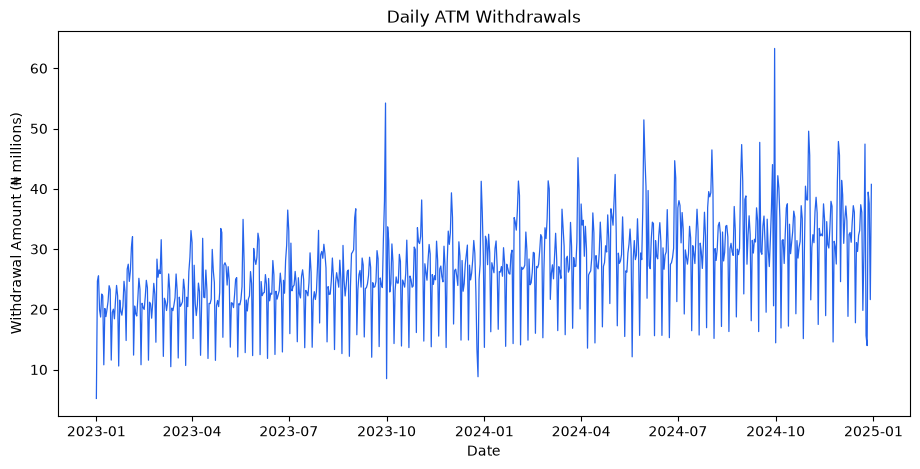

In [8]:
fig, ax = plt.subplots()
ax.plot(df["Date"], df["WithdrawalAmount"] / 1e6, color="#2563EB", linewidth=0.9)
ax.set_xlabel("Date")
ax.set_ylabel("Withdrawal Amount (₦ millions)")
ax.set_title("Daily ATM Withdrawals")
plt.show()

**Look at the chart above and ask yourself:**
- Is there a trend? (Does the general level rise or fall over the two years?)
- Is there seasonality? (Does a pattern repeat at a regular interval?)
- Are there unusual spikes? (Any points that jump far above or below their neighbours?)

Try to form your own answer before reading on.

### A closer look: trend

Let's smooth the series with a 30-day rolling average to make the underlying trend easier to see
through the day-to-day noise.

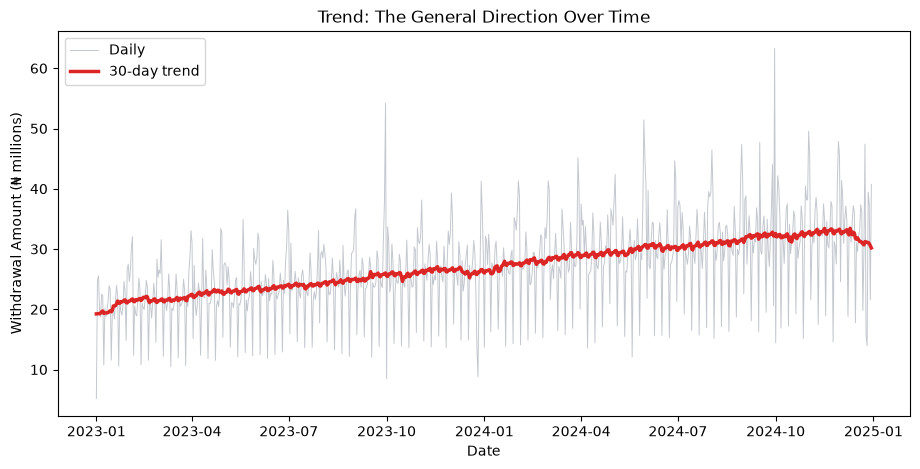

In [9]:
fig, ax = plt.subplots()
ax.plot(df["Date"], df["WithdrawalAmount"] / 1e6, color="#9CA3AF", linewidth=0.7, alpha=0.6, label="Daily")
trend = df["WithdrawalAmount"].rolling(30, center=True, min_periods=1).mean() / 1e6
ax.plot(df["Date"], trend, color="#DC2626", linewidth=2.5, label="30-day trend")
ax.set_xlabel("Date")
ax.set_ylabel("Withdrawal Amount (₦ millions)")
ax.set_title("Trend: The General Direction Over Time")
ax.legend()
plt.show()

**What do we see?** A gentle, fairly steady upward trend — the bank's cash demand is growing over the two years.

### A closer look: weekly seasonality

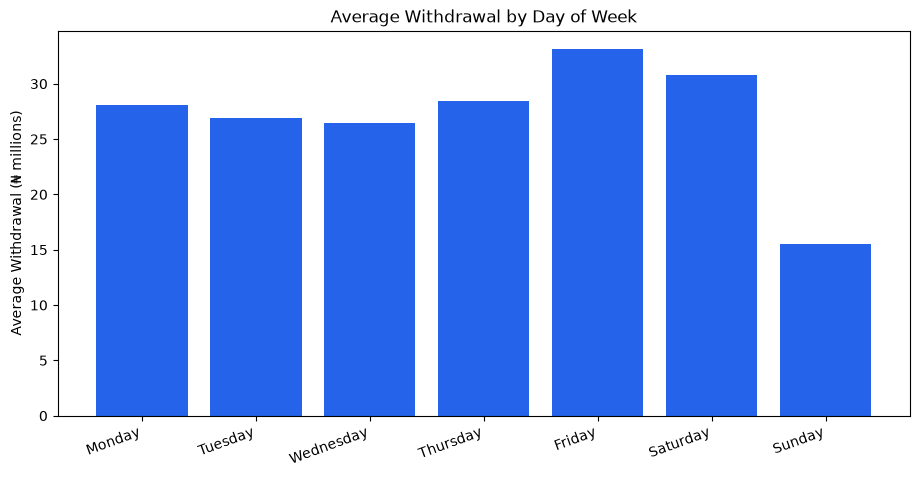

DayOfWeek
Monday       28.1
Tuesday      26.9
Wednesday    26.4
Thursday     28.5
Friday       33.1
Saturday     30.8
Sunday       15.5
Name: WithdrawalAmount, dtype: float64

In [10]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_avg = df.groupby("DayOfWeek")["WithdrawalAmount"].mean().reindex(dow_order) / 1e6

fig, ax = plt.subplots()
ax.bar(dow_order, dow_avg, color="#2563EB")
ax.set_ylabel("Average Withdrawal (₦ millions)")
ax.set_title("Average Withdrawal by Day of Week")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.show()

dow_avg.round(1)

**What do we see?** A clear, consistent weekly pattern — Fridays and Saturdays are the busiest, and Sundays are by far the quietest (most branches closed). This is seasonality: a pattern that repeats at a REGULAR interval, every 7 days.

### Recap
- We loaded the raw CSV and converted `Date` to a real datetime column.
- We explicitly sorted the data by time — never assume a file is already in order.
- We visualized the full series and confirmed, with our own eyes, both a trend AND weekly
  seasonality before writing a single line of modeling code.

**Next: `02_Moving_Averages_and_Lags.ipynb`** — where we turn these patterns into features a
model can actually use.